## I. Import

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load raw data
url = 'https://raw.githubusercontent.com/jldbc/coffee-quality-database/master/data/arabica_data_cleaned.csv'
df_raw = pd.read_csv(url)

print("Loaded raw dataset, shape:", df_raw.shape)
df_raw.head()

Loaded raw dataset, shape: (1311, 44)


,Unnamed: 0,Species,Owner,Country.of.Origin,Farm.Name,Lot.Number,Mill,ICO.Number,Company,Altitude,...,Color,Category.Two.Defects,Expiration,Certification.Body,Certification.Address,Certification.Contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,1,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,2,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,3,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,...,NaN,0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0
3,4,Arabica,yidnekachew dabessa,Ethiopia,yidnekachew dabessa coffee plantation,NaN,wolensu,NaN,yidnekachew debessa coffee plantation,1800-2200,...,Green,2,"March 25th, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1800.0,2200.0,2000.0
4,5,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,2,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0


In [2]:
# Rename columns to snake_case for consistency
df_raw.columns = (
    df_raw.columns
    .str.replace('.', '_', regex=False)   # periods to underscores
    .str.replace(' ', '_', regex=False)   # spaces to underscores
    .str.lower()                          # lowercases everything
)

df_raw.dtypes

,0
unnamed:_0,int64
species,object
owner,object
country_of_origin,object
farm_name,object
lot_number,object
mill,object
ico_number,object
company,object
altitude,object


## II. Data Preprocessing


### II.0 check all columns

In [3]:
# ============================================================
# II.0 — Initial data exploration
# Column-level summary — cardinality, missingness, dtype
# ============================================================

print(f"Dataset shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print(f"Duplicates: {df_raw.duplicated().sum()}")

summary = pd.DataFrame({
    'dtype':        df_raw.dtypes.astype(str),
    'n_unique':     df_raw.nunique(),
    'n_missing':    df_raw.isnull().sum(),
    'pct_missing': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})

print("\nCOLUMN-LEVEL SUMMARY (all 44 columns)")
print("=" * 80)
print(summary)

Dataset shape: 1311 rows × 44 columns
Duplicates: 0

COLUMN-LEVEL SUMMARY (all 44 columns)
                         dtype  n_unique  n_missing  pct_missing
unnamed:_0               int64      1311          0         0.00
species                 object         1          0         0.00
owner                   object       305          7         0.53
country_of_origin       object        36          1         0.08
farm_name               object       557        356        27.15
lot_number              object       221       1041        79.41
mill                    object       447        310        23.65
ico_number              object       840        148        11.29
company                 object       270        209        15.94
altitude                object       383        223        17.01
region                  object       343         57         4.35
producer                object       675        230        17.54
number_of_bags           int64       130          0         0.00

### II.1 drop irrelevant columns

In [4]:
# ============================================================
# II.1 — Drop non-predictive and redundant columns
# ============================================================

# Administrative identifiers — not predictive of coffee quality
admin_cols = [
    'unnamed:_0', 'owner', 'farm_name', 'lot_number', 'mill', 'ico_number',
    'company', 'producer', 'in_country_partner', 'owner_1',
    'certification_body', 'certification_address', 'certification_contact'
] # len=13

# Redundant or to-be-replaced columns
redundant_cols = [
    'species',      # 100% Arabica
    'region',       # 343 unique regions: too high-cardinality
    'number_of_bags', 'bag_weight',
    'grading_date', 'expiration',
    'unit_of_measurement', 'altitude_low_meters',
    'altitude_high_meters', 'altitude_mean_meters',
] # len=10

df = df_raw.drop(columns=admin_cols + redundant_cols, errors='ignore').copy()

print(f"Dropped {len(admin_cols)} administrative + {len(redundant_cols)} redundant columns")
print(f"Current dataset shape: {df.shape}")

Dropped 13 administrative + 10 redundant columns
Current dataset shape: (1311, 21)


altitude and harvest_year wrong type; inspect further before converting to numerical type


### II.2 missing values

In [5]:
# ============================================================
# II.2 — Data preprocessing
# ============================================================

print("Missing values per column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'count': missing, 'percent': missing_pct})
print(missing_report[missing_report['count'] > 0].sort_values('count', ascending=False))

# Drop the data-error row (total_cup_points == 0)
df = df[df['total_cup_points'] > 0].copy()
df.describe().T

Missing values per column:
                   count  percent
color                267    20.37
altitude             223    17.01
variety              201    15.33
processing_method    152    11.59
harvest_year          47     3.59
country_of_origin      1     0.08
quakers                1     0.08


,count,mean,std,min,25%,50%,75%,max
aroma,1310.0,7.569580,0.315845,5.08,7.42,7.58,7.75,8.75
flavor,1310.0,7.523809,0.341897,6.08,7.33,7.58,7.75,8.83
aftertaste,1310.0,7.403344,0.349867,6.17,7.25,7.42,7.58,8.67
acidity,1310.0,7.538863,0.319912,5.25,7.33,7.50,7.75,8.75
body,1310.0,7.523466,0.293129,5.25,7.33,7.50,7.67,8.58
balance,1310.0,7.523244,0.349304,6.08,7.33,7.50,7.75,8.75
uniformity,1310.0,9.840901,0.489058,6.00,10.00,10.00,10.00,10.00
clean_cup,1310.0,9.840626,0.722158,0.00,10.00,10.00,10.00,10.00
sweetness,1310.0,9.910832,0.454991,1.33,10.00,10.00,10.00,10.00
cupper_points,1310.0,7.503588,0.427138,5.17,7.25,7.50,7.75,10.00


all numerical columns, but `altitude` and `harvest_year`, look good (need dtype conversion)

In [6]:
# Build the target: Quality Tier
# Thresholds from Specialty Coffee Association industry standards
def quality_tier(score):
    if score < 80:   return 'commercial'
    elif score < 85: return 'premium'
    else:            return 'specialty'

df['quality_tier'] = df['total_cup_points'].apply(quality_tier)
df['quality_tier'].value_counts(normalize=True)

,proportion
quality_tier,
premium,0.781679
commercial,0.137405
specialty,0.080916


### II.3 altitude cleanup

In [7]:
# ============================================================
# II.3 — Altitude parser (exploration)
# ============================================================

# Look at a sample of raw values to understand formatting
df['altitude'].dropna().sample(25, random_state=42).tolist()

['940',
 '1950',
 '1000-1500m',
 '1650',
 '1550',
 '1000 m',
 '1525 m',
 '800',
 '1650',
 '1000 msnm',
 '1300 m',
 '1200m',
 '1500 msnm',
 '200 m',
 '1300',
 '1100',
 '1200',
 '1850',
 '1500',
 '800公尺',
 '600 m',
 '1450',
 '16.8',
 '4200 feet',
 '1800 - 2000']

In [8]:
# Look at rows with implausibly high altitude
df_raw[df_raw['altitude_mean_meters'] > 3000][
    ['country_of_origin', 'altitude', 'altitude_mean_meters', 'altitude_low_meters', 'altitude_high_meters', 'unit_of_measurement']
]

,country_of_origin,altitude,altitude_mean_meters,altitude_low_meters,altitude_high_meters,unit_of_measurement
215,Guatemala,3280,3280.0,3280.0,3280.0,m
543,Brazil,11000 metros,11000.0,11000.0,11000.0,m
628,Colombia,1800 meters (5900,3850.0,1800.0,5900.0,m
837,Guatemala,3280,3280.0,3280.0,3280.0,m
840,Myanmar,4001,4001.0,4001.0,4001.0,m
896,Guatemala,190164,190164.0,190164.0,190164.0,m
1001,Guatemala,3280,3280.0,3280.0,3280.0,m
1038,Myanmar,3825,3825.0,3825.0,3825.0,m
1040,Nicaragua,1100.00 mosl,110000.0,110000.0,110000.0,m
1073,Myanmar,3800,3800.0,3800.0,3800.0,m


In [9]:
df_raw[(df_raw['altitude'] == '3280') & (df_raw['country_of_origin'] == 'Guatemala')][
    ['country_of_origin', 'altitude', 'altitude_mean_meters', 'unit_of_measurement']
]

,country_of_origin,altitude,altitude_mean_meters,unit_of_measurement
215,Guatemala,3280,3280.0,m
837,Guatemala,3280,3280.0,m
1001,Guatemala,3280,3280.0,m


In [10]:
df_raw[df_raw['unit_of_measurement'] != 'm'][
    ['country_of_origin', 'altitude', 'altitude_mean_meters', 'unit_of_measurement']
]

,country_of_origin,altitude,altitude_mean_meters,unit_of_measurement
13,United States (Hawaii),2000 ft,609.60,ft
36,United States (Hawaii),NaN,NaN,ft
37,United States (Hawaii),NaN,NaN,ft
51,United States (Hawaii),1400ft,426.72,ft
57,Guatemala,5000,1524.00,ft
...,...,...,...,...
1286,United States (Hawaii),NaN,NaN,ft
1287,Guatemala,4300,1310.64,ft
1291,United States (Hawaii),NaN,NaN,ft
1296,United States (Hawaii),NaN,NaN,ft


In [11]:
# ============================================================
# II.3 — Altitude parser (cleaning)
# ============================================================

def parse_altitude(raw):
    """
    Parse messy altitude strings into a clean value in meters.
    Handles: plain numbers, ranges, unit suffixes (m, msnm, feet, 公尺),
    and implausible values.
    Returns NaN for unparseable or biologically impossible entries.
    """
    if pd.isna(raw):
        return np.nan
    s = str(raw).strip().lower()

    # Extract all numbers (including decimals)
    numbers = re.findall(r'\d+\.?\d*', s)
    if not numbers:
        return np.nan
    numbers = [float(n) for n in numbers]

    # If it's a range, take the midpoint
    value = (numbers[0] + numbers[1]) / 2 if len(numbers) >= 2 else numbers[0]

    # Detect feet and convert to meters
    if any(kw in s for kw in ['feet', 'ft', "'"]):
        value *= 0.3048

    # Coffee grows between ~100m and ~3000m — flag anything else
    if value < 100 or value > 3000:
        return np.nan

    return round(value, 1)

df['altitude_clean_m'] = df['altitude'].apply(parse_altitude)
df['altitude_clean_m'].describe()

,altitude_clean_m
count,948.000000
mean,1324.836709
std,382.482274
min,100.000000
25%,1100.000000
50%,1350.000000
75%,1600.000000
max,2560.000000


In [12]:
# Impute missing altitudes using the country's median altitude

country_median_alt = df.groupby('country_of_origin')['altitude_clean_m'].median()

df['altitude_imputed_m'] = df.apply(
    lambda r: r['altitude_clean_m'] if pd.notna(r['altitude_clean_m'])
              else country_median_alt.get(r['country_of_origin'], np.nan),
    axis=1
)

# Drop remaining rows (country has no altitude data anywhere)
df = df.dropna(subset=['altitude_imputed_m']).copy()

print(f"Rows after altitude imputation: {len(df)}")
df['altitude_imputed_m'].describe()

Rows after altitude imputation: 1308


,altitude_imputed_m
count,1308.000000
mean,1300.921674
std,398.385108
min,100.000000
25%,1044.250000
50%,1350.000000
75%,1600.000000
max,2560.000000


In [13]:
# altitude has been replaced by altitude_imputed_m
df = df.drop(columns=['altitude', 'altitude_clean_m'])
df.dtypes

,0
country_of_origin,object
harvest_year,object
variety,object
processing_method,object
aroma,float64
flavor,float64
aftertaste,float64
acidity,float64
body,float64
balance,float64


### II.4 harvest year cleanup

In [14]:
# ============================================================
# II.4 — Harvest year parser (exploration)
# ============================================================

print(f"Unique values: {df['harvest_year'].nunique()}")
print(f"Missing: {df['harvest_year'].isna().sum()}")

# Show every unique format we have to handle
sorted(df['harvest_year'].dropna().unique().tolist())

Unique values: 46
Missing: 46


['08/09 crop',
 '1T/2011',
 '1t/2011',
 '2009 - 2010',
 '2009 / 2010',
 '2009-2010',
 '2009/2010',
 '2010',
 '2010-2011',
 '2011',
 '2011/2012',
 '2012',
 '2013',
 '2013/2014',
 '2014',
 '2014/2015',
 '2015',
 '2015/2016',
 '2016',
 '2016 / 2017',
 '2016/2017',
 '2017',
 '2017 / 2018',
 '2018',
 '23 July 2010',
 '3T/2011',
 '47/2010',
 '4T/10',
 '4T/2010',
 '4T72010',
 '4t/2010',
 '4t/2011',
 'Abril - Julio',
 'Abril - Julio /2011',
 'August to December',
 'December 2009-March 2010',
 'Fall 2009',
 'January 2011',
 'January Through April',
 'March 2010',
 'May-August',
 'Mayo a Julio',
 'Sept 2009 - April 2010',
 'Spring 2011 in Colombia.',
 'TEST',
 'mmm']

In [15]:
# ============================================================
# II.4 — Harvest year parser (cleaning)
# ============================================================

def parse_harvest_year(raw):
    """
    Extract harvest year from messy text. Returns int or NaN.
    Strategy: look for any 4-digit year in range 2000-2029, or
    2-digit year codes after a separator (e.g., '08/09', '4T/10').
    """
    if pd.isna(raw):
        return np.nan
    s = str(raw).strip().lower()

    # Reject obvious junk
    if s in ('test', 'mmm', ''):
        return np.nan

    # Find 4-digit years in a plausible range; if ranges, take later
    four_digit = re.findall(r'\b(20[0-2]\d)\b', s)
    if four_digit:
        return int(max(four_digit))

    # Find 2-digit years like "08/09" or "4T/10" (take later year)
    two_digit = re.findall(r'/(\d{2})\b', s)
    if two_digit:
        y = int(max(two_digit))
        return 2000 + y if y <= 29 else 1900 + y

    return np.nan

df['harvest_year_clean'] = df['harvest_year'].apply(parse_harvest_year)
df['harvest_year_clean'].describe()

,harvest_year_clean
count,1251.000000
mean,2013.650679
std,1.847452
min,2009.000000
25%,2012.000000
50%,2014.000000
75%,2015.000000
max,2018.000000


In [16]:
# Drop rows with unparseable harvest year and set dtype to int
df = df.dropna(subset=['harvest_year_clean']).copy()
df['harvest_year_clean'] = df['harvest_year_clean'].astype(int)

# Drop the original messy column
df = df.drop(columns=['harvest_year'])

print(f"Rows after harvest year cleaning: {len(df)}")
df.dtypes

Rows after harvest year cleaning: 1251


,0
country_of_origin,object
variety,object
processing_method,object
aroma,float64
flavor,float64
aftertaste,float64
acidity,float64
body,float64
balance,float64
uniformity,float64


### II.5 variety grouping

In [17]:
# ============================================================
# II.5 — Variety normalization (exploration)
# ============================================================

print(f"Unique varieties: {df['variety'].nunique()}")
print(f"Missing: {df['variety'].isna().sum()}")

df['variety'].value_counts(dropna=False)

Unique varieties: 29
Missing: 156


,count
variety,
Caturra,252
Bourbon,224
Typica,211
NaN,156
Other,108
Catuai,72
Hawaiian Kona,44
Yellow Bourbon,35
Mundo Novo,32


In [18]:
# ============================================================
# II.5 — Variety normalization (cleaning)
# ============================================================

def normalize_variety(v):
    """Group 29 raw varieties into ~10 botanical families."""
    if pd.isna(v):
        return 'Unknown'
    v = str(v).strip()

    # Bourbon family (Yellow Bourbon is just a color variant of Bourbon)
    if v in ['Bourbon', 'Yellow Bourbon']:
        return 'Bourbon'
    # Typica family (Mundo Novo, Blue Mountain, Java are all Typica-related)
    if v in ['Typica', 'Mundo Novo', 'Blue Mountain', 'Java']:
        return 'Typica'
    # Kenyan SL varieties (bred for cup quality)
    if v in ['SL14', 'SL28', 'SL34']:
        return 'SL_Kenyan'
    # Rare specialty varieties (Gesha, Pacamara, etc.)
    if v in ['Gesha', 'Pacamara', 'Pacas', 'Marigojipe', 'Peaberry', 'Moka Peaberry']:
        return 'Specialty'
    # Common varieties kept as-is
    if v in ['Caturra', 'Catuai', 'Catimor', 'Hawaiian Kona']:
        return v
    # Everything else (Arusha, Ruiru 11, Sumatran, Ethiopian, Sulawesi, Pache Comun, 'Other')
    return 'Other'

df['variety_group'] = df['variety'].apply(normalize_variety)
df = df.drop(columns=['variety'])

df['variety_group'].value_counts()

,count
variety_group,
Bourbon,259
Caturra,252
Typica,247
Unknown,156
Other,127
Catuai,72
Hawaiian Kona,44
SL_Kenyan,38
Specialty,36


### II.6 processing method cleanup

In [19]:
# ============================================================
# II.6 — Processing method normalization (exploration)
# ============================================================

print(f"Unique values: {df['processing_method'].nunique()}")
print(f"Missing: {df['processing_method'].isna().sum()}")

df['processing_method'].value_counts(dropna=False)

Unique values: 5
Missing: 100


,count
processing_method,
Washed / Wet,808
Natural / Dry,249
NaN,100
Semi-washed / Semi-pulped,56
Other,26
Pulped natural / honey,12


In [20]:
# ============================================================
# II.6 — Processing method normalization (cleaning)
# ============================================================

def normalize_processing(p):
    """Shorten labels and merge small categories into the closest match."""
    if pd.isna(p):
        return 'Unknown'
    p = str(p).strip()
    if p == 'Washed / Wet':
        return 'Washed'
    if p == 'Natural / Dry':
        return 'Natural'
    # Both are intermediate processing — merge to reach a workable sample size
    if p in ['Semi-washed / Semi-pulped', 'Pulped natural / honey']:
        return 'Semi-washed'
    return 'Other'

df['processing_group'] = df['processing_method'].apply(normalize_processing)
df = df.drop(columns=['processing_method'])

df['processing_group'].value_counts()

,count
processing_group,
Washed,808
Natural,249
Unknown,100
Semi-washed,68
Other,26


### II.7 color cleanup

In [21]:
# ============================================================
# II.7 — Color normalization (exploration)
# ============================================================

print(f"Unique values: {df['color'].nunique()}")
print(f"Missing: {df['color'].isna().sum()}")

vc = df['color'].value_counts(dropna=False)
vc_norm = df['color'].value_counts(dropna=False, normalize=True)
pd.DataFrame({'count': vc, 'percent': vc_norm.mul(100).round(2)})

Unique values: 3
Missing: 220


,count,percent
color,,
Green,839,67.07
NaN,220,17.59
Bluish-Green,112,8.95
Blue-Green,80,6.39


In [22]:
# ============================================================
# II.7 — Color normalization (cleaning)
# ============================================================

def normalize_color(c):
    """Merge blue variants."""
    if pd.isna(c):
        return 'Unknown'
    c = str(c).strip()
    if c in ['Bluish-Green', 'Blue-Green']:
        return 'Blue-Green'
    if c == 'Green':
        return 'Green'
    return 'Other'

df['color_group'] = df['color'].apply(normalize_color)
df = df.drop(columns=['color'])

vc = df['color_group'].value_counts(dropna=False)
vc_norm = df['color_group'].value_counts(dropna=False, normalize=True)
pd.DataFrame({'count': vc, 'percent': vc_norm.mul(100).round(2)})

,count,percent
color_group,,
Green,839,67.07
Unknown,220,17.59
Blue-Green,192,15.35


### II.8 country to region grouping

In [23]:
# ============================================================
# II.8 — Country to region grouping (exploration)
# ============================================================

print(f"Unique countries: {df['country_of_origin'].nunique()}")
print(f"Missing: {df['country_of_origin'].isna().sum()}")

df['country_of_origin'].value_counts(dropna=False)

Unique countries: 34
Missing: 0


,count
country_of_origin,
Mexico,235
Guatemala,177
Colombia,172
Brazil,127
Taiwan,75
United States (Hawaii),54
Honduras,52
Costa Rica,49
Ethiopia,42


In [24]:
# ============================================================
# II.8 — Country to region grouping (cleaning)
# ============================================================
# Regional scheme based on International Coffee Organization (ICO) geographic
# groupings. Countries within each region share similar climate, altitude
# ranges, and processing traditions.

regions = {
    'Central America': ['Mexico', 'Guatemala', 'Honduras', 'Costa Rica',
                        'Nicaragua', 'El Salvador', 'Panama'],

    'South America':   ['Colombia', 'Brazil', 'Peru', 'Ecuador'],

    'East Africa':     ['Ethiopia', 'Tanzania, United Republic Of', 'Uganda',
                        'Kenya', 'Malawi', 'Burundi', 'Rwanda', 'Zambia',
                        'Cote d?Ivoire'],

    'Southeast Asia':  ['Taiwan', 'Thailand', 'Indonesia', 'China', 'Myanmar',
                        'Vietnam', 'Philippines', 'Laos', 'Papua New Guinea'],

    'Caribbean/US':    ['United States (Hawaii)', 'Haiti', 'Mauritius',
                        'United States (Puerto Rico)', 'United States'],
}

# Flatten into country → region lookup
region_map = {country: region for region, countries in regions.items()
                              for country in countries}

df['region_group'] = df['country_of_origin'].map(region_map)
df = df.drop(columns=['country_of_origin'])

vc = df['region_group'].value_counts(dropna=False)
vc_norm = df['region_group'].value_counts(dropna=False, normalize=True)
pd.DataFrame({'count': vc, 'percent': vc_norm.mul(100).round(2)})

,count,percent
region_group,,
Central America,561,44.84
South America,309,24.70
Southeast Asia,161,12.87
East Africa,147,11.75
Caribbean/US,73,5.84


### II.9 moisture cleanup

In [25]:
# ============================================================
# II.9 — Moisture cleanup (exploration)
# ============================================================

print(f"Zero values in moisture: {(df['moisture'] == 0).sum()}")
print(f"Missing values: {df['moisture'].isna().sum()}")

df['moisture'].describe()

Zero values in moisture: 229
Missing values: 0


,moisture
count,1251.000000
mean,0.090799
std,0.046733
min,0.000000
25%,0.100000
50%,0.110000
75%,0.120000
max,0.280000


In [26]:
# Compute regional medians from valid (non-zero) moisture readings only
df[df['moisture'] > 0].groupby('region_group')['moisture'].agg(
    ['median', 'mean', 'std', 'count']
).round(3)

,median,mean,std,count
region_group,,,,
Caribbean/US,0.11,0.106,0.024,47
Central America,0.11,0.113,0.016,518
East Africa,0.12,0.111,0.024,133
South America,0.11,0.107,0.021,201
Southeast Asia,0.11,0.111,0.027,123


In [27]:
# ============================================================
# II.9 — Moisture cleanup (cleaning)
# ============================================================
# Zero moisture is physically impossible for green coffee (typical range 10-12%).
# We treat these as hidden missingness and impute with the median of valid values.

moisture_median = df.loc[df['moisture'] > 0, 'moisture'].median()
df.loc[df['moisture'] == 0, 'moisture'] = moisture_median

print(f"Imputed {229} zero-moisture values with median {moisture_median:.3f}")
df['moisture'].describe()

Imputed 229 zero-moisture values with median 0.110


,moisture
count,1251.000000
mean,0.110935
std,0.018313
min,0.010000
25%,0.110000
50%,0.110000
75%,0.120000
max,0.280000


### II.10 quakers missing value

In [28]:
# ============================================================
# II.10 — Quakers: fill single missing value
# ============================================================
# 92.7% of quakers values are 0 (mode). The single missing value is filled with 0.

n_missing = df['quakers'].isna().sum()
df['quakers'] = df['quakers'].fillna(0)

print(f"Filled {n_missing} missing quakers value with 0 (mode)")
df['quakers'].describe()

Filled 1 missing quakers value with 0 (mode)


,quakers
count,1251.000000
mean,0.169464
std,0.804027
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,11.000000


### II.11 chi-square check on categoricals

In [29]:
# ============================================================
# Decision check: which categorical features are associated with quality_tier?
# ============================================================

categorical_features = ['variety_group', 'processing_group', 'color_group', 'region_group']

print(f"{'Feature':<20} {'Chi-square':>12} {'dof':>6} {'p-value':>14}")
print("-" * 60)
for col in categorical_features:
    ct = pd.crosstab(df[col], df['quality_tier'])
    chi2, p, dof, expected = chi2_contingency(ct)
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    print(f"{col:<20} {chi2:>12.2f} {dof:>6} {p:>14.2e}  {sig}")

print("\nSignificance: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant")

Feature                Chi-square    dof        p-value
------------------------------------------------------------
variety_group              126.41     18       2.57e-18  ***
processing_group            47.78      8       1.09e-07  ***
color_group                 42.08      4       1.60e-08  ***
region_group               188.98      8       1.34e-36  ***

Significance: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant


### II.12 drop color_group

In [30]:
# ============================================================
# Drop color_group — weakest categorical association with target
# ============================================================
# Chi-square ranking: region_group (189) > variety_group (126) > processing_group (48) > color_group (42)
# Color also had the highest missingness (17.6%) among categoricals.
# Dropped to reduce model complexity without meaningful loss of signal.

df = df.drop(columns=['color_group'])

print(f"Final dataset: {df.shape[0]} rows × {df.shape[1]} columns")

Final dataset: 1251 rows × 21 columns


## III. EDA

In [31]:
# ============================================================
# III — Exploratory Data Analysis
# ============================================================

# Feature groupings used throughout the analysis
numeric_production = ['altitude_imputed_m', 'harvest_year_clean', 'moisture',
                      'category_one_defects', 'category_two_defects', 'quakers']

sensory_features = ['aroma', 'flavor', 'aftertaste', 'acidity', 'body',
                    'balance', 'uniformity', 'clean_cup', 'sweetness', 'cupper_points']

categorical_features = ['variety_group', 'processing_group', 'region_group']

tier_order = ['commercial', 'premium', 'specialty']

print(f"Numeric production features: {len(numeric_production)}")
print(f"Sensory scores: {len(sensory_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Target classes: {tier_order}")

Numeric production features: 6
Sensory scores: 10
Categorical features: 3
Target classes: ['commercial', 'premium', 'specialty']


### III.1 target distribution

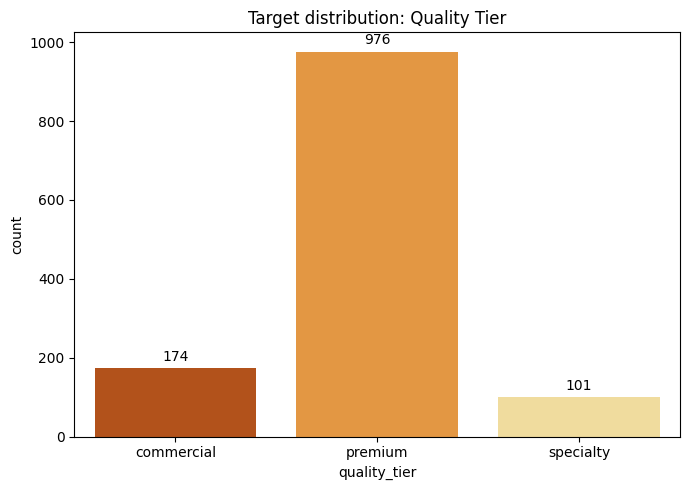

,proportion
quality_tier,
commercial,13.9
premium,78.0
specialty,8.1


In [32]:
# ============================================================
# III.1 — Target distribution
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(data=df, x='quality_tier', order=tier_order,
              hue='quality_tier', palette='YlOrBr', legend=False, ax=ax)
for container in ax.containers:
    ax.bar_label(container, padding=3)
ax.set_title('Target distribution: Quality Tier')
plt.tight_layout()
plt.show()

# Print the percentages for the report
df['quality_tier'].value_counts(normalize=True).mul(100).round(1).reindex(tier_order)

### III.2 numeric production univariate

Descriptive statistics:
                       count      mean      std      min      25%      50%  \
altitude_imputed_m    1251.0  1310.676  390.036   100.00  1054.50  1350.00   
harvest_year_clean    1251.0  2013.651    1.847  2009.00  2012.00  2014.00   
moisture              1251.0     0.111    0.018     0.01     0.11     0.11   
category_one_defects  1251.0     0.420    1.838     0.00     0.00     0.00   
category_two_defects  1251.0     3.662    5.410     0.00     0.00     2.00   
quakers               1251.0     0.169    0.804     0.00     0.00     0.00   

                          75%      max  
altitude_imputed_m    1600.00  2560.00  
harvest_year_clean    2015.00  2018.00  
moisture                 0.12     0.28  
category_one_defects     0.00    31.00  
category_two_defects     4.50    55.00  
quakers                  0.00    11.00  


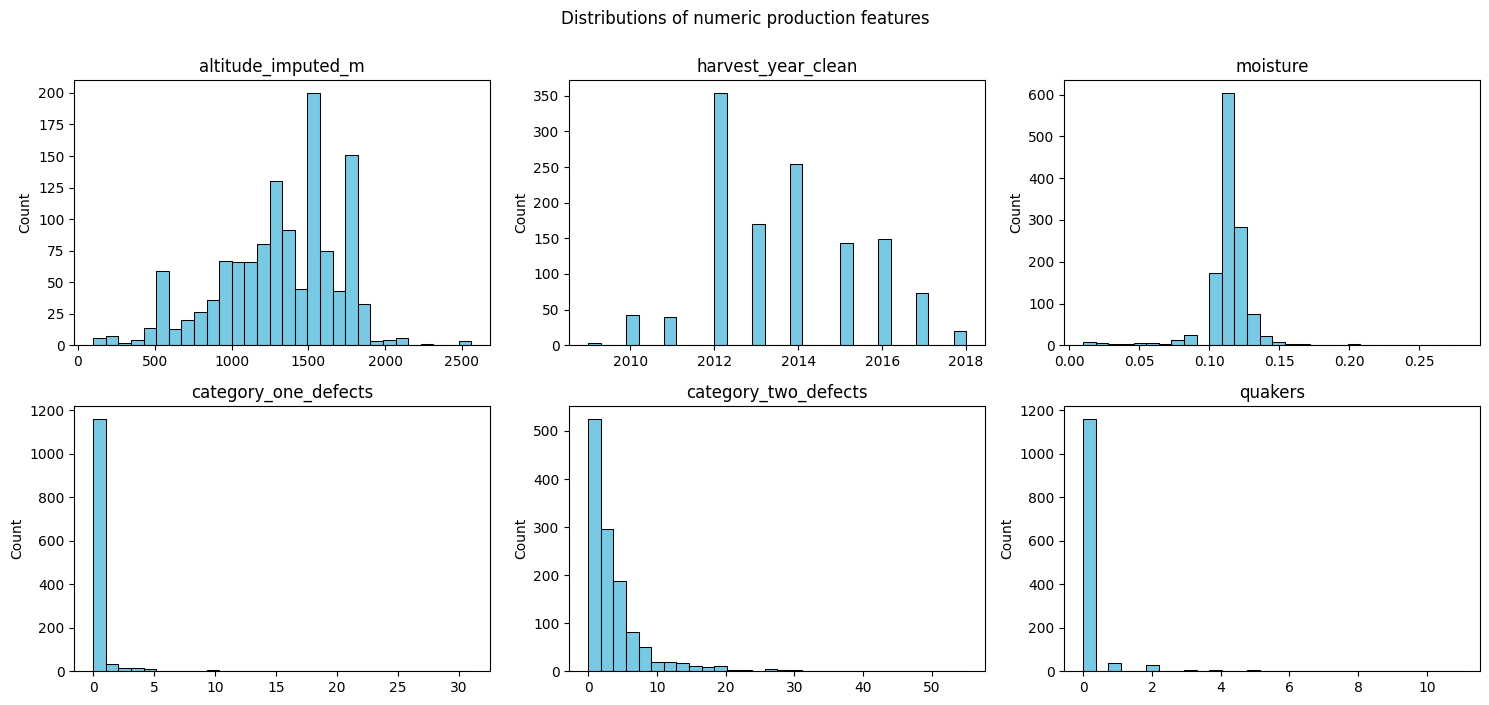

In [33]:
# ============================================================
# III.2 — Univariate: numeric production features
# ============================================================

print("Descriptive statistics:")
print(df[numeric_production].describe().round(3).T)

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flatten(), numeric_production):
    sns.histplot(df[col], bins=30, color='#4ab8dc', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Distributions of numeric production features', y=1.00)
plt.tight_layout()
plt.show()

### III.3 sensory score univariate

Descriptive statistics:
                count  mean   std   min    25%    50%    75%    max
aroma          1251.0  7.57  0.32  5.08   7.42   7.58   7.75   8.75
flavor         1251.0  7.52  0.34  6.08   7.33   7.50   7.75   8.83
aftertaste     1251.0  7.40  0.35  6.17   7.25   7.42   7.58   8.67
acidity        1251.0  7.54  0.32  5.25   7.33   7.50   7.75   8.75
body           1251.0  7.52  0.29  5.25   7.33   7.50   7.67   8.58
balance        1251.0  7.52  0.35  6.08   7.33   7.50   7.75   8.75
uniformity     1251.0  9.85  0.49  6.00  10.00  10.00  10.00  10.00
clean_cup      1251.0  9.84  0.74  0.00  10.00  10.00  10.00  10.00
sweetness      1251.0  9.91  0.45  1.33  10.00  10.00  10.00  10.00
cupper_points  1251.0  7.50  0.43  5.17   7.25   7.50   7.75  10.00


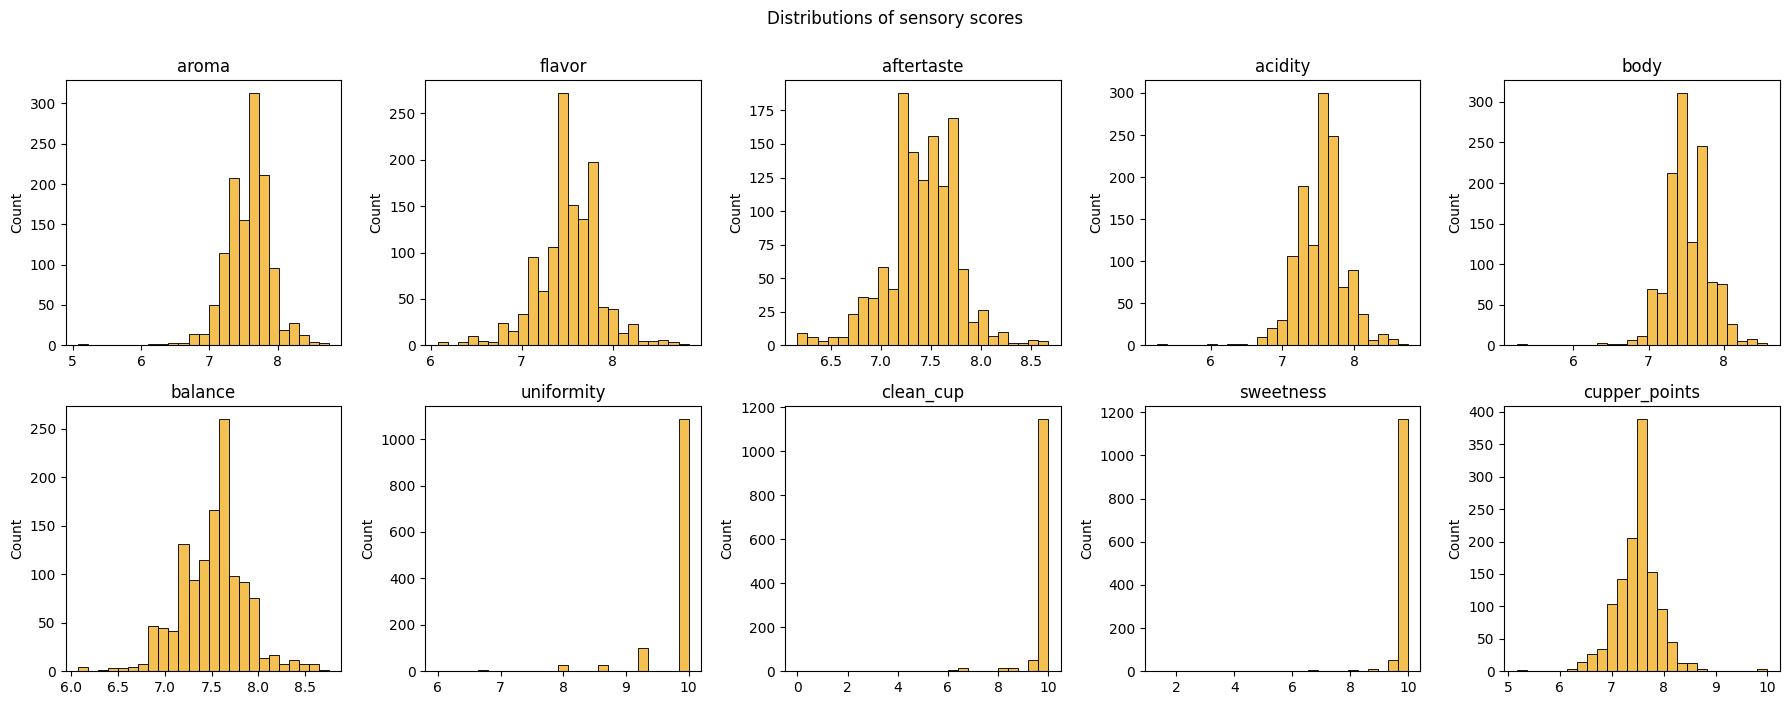

In [34]:
# ============================================================
# III.3 — Univariate: sensory scores
# ============================================================

print("Descriptive statistics:")
print(df[sensory_features].describe().round(2).T)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.flatten(), sensory_features):
    sns.histplot(df[col], bins=25, color='#f1ab17', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Distributions of sensory scores', y=1.00)
plt.tight_layout()
plt.show()

### III.4 categorical univariate

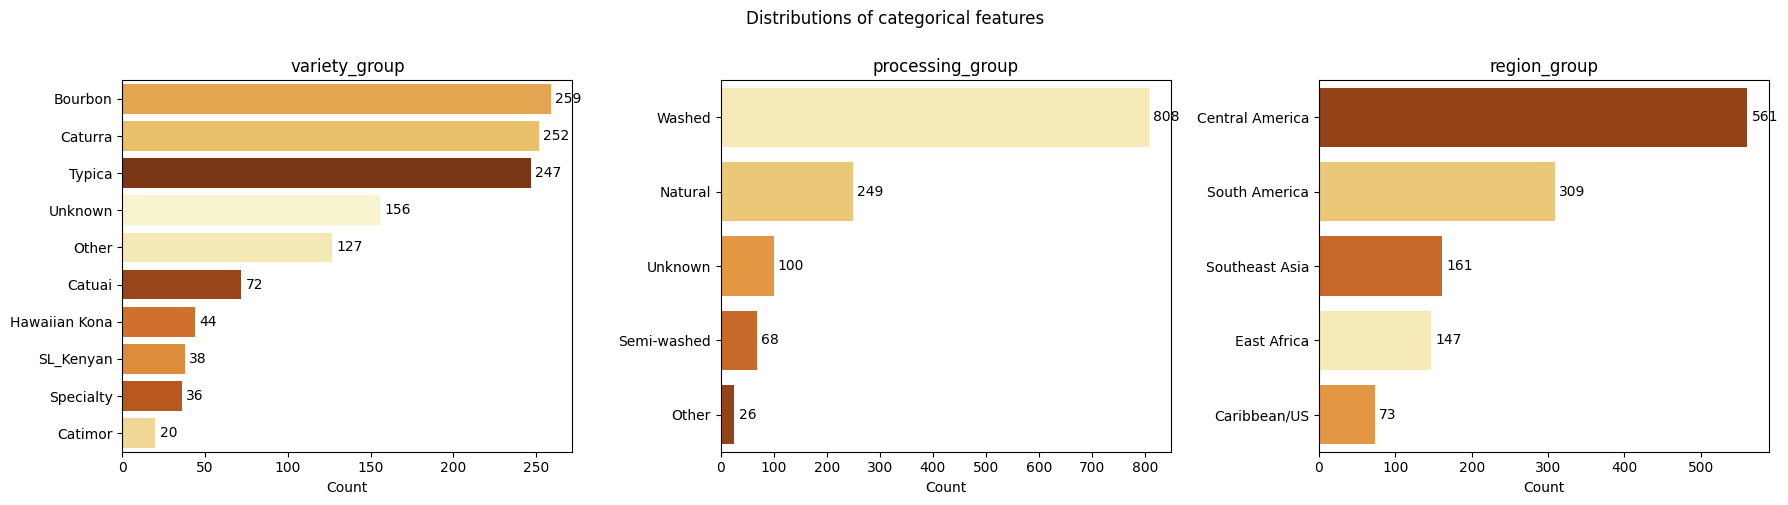

In [35]:
# ============================================================
# III.4 — Univariate: categorical features
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, categorical_features):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order,
                  hue=col, palette='YlOrBr', legend=False, ax=ax)
    for container in ax.containers:
        ax.bar_label(container, padding=3)
    ax.set_title(col)
    ax.set_xlabel('Count')
    ax.set_ylabel('')
plt.suptitle('Distributions of categorical features', y=1.00)
plt.tight_layout()
plt.show()

### III.5 numeric vs target

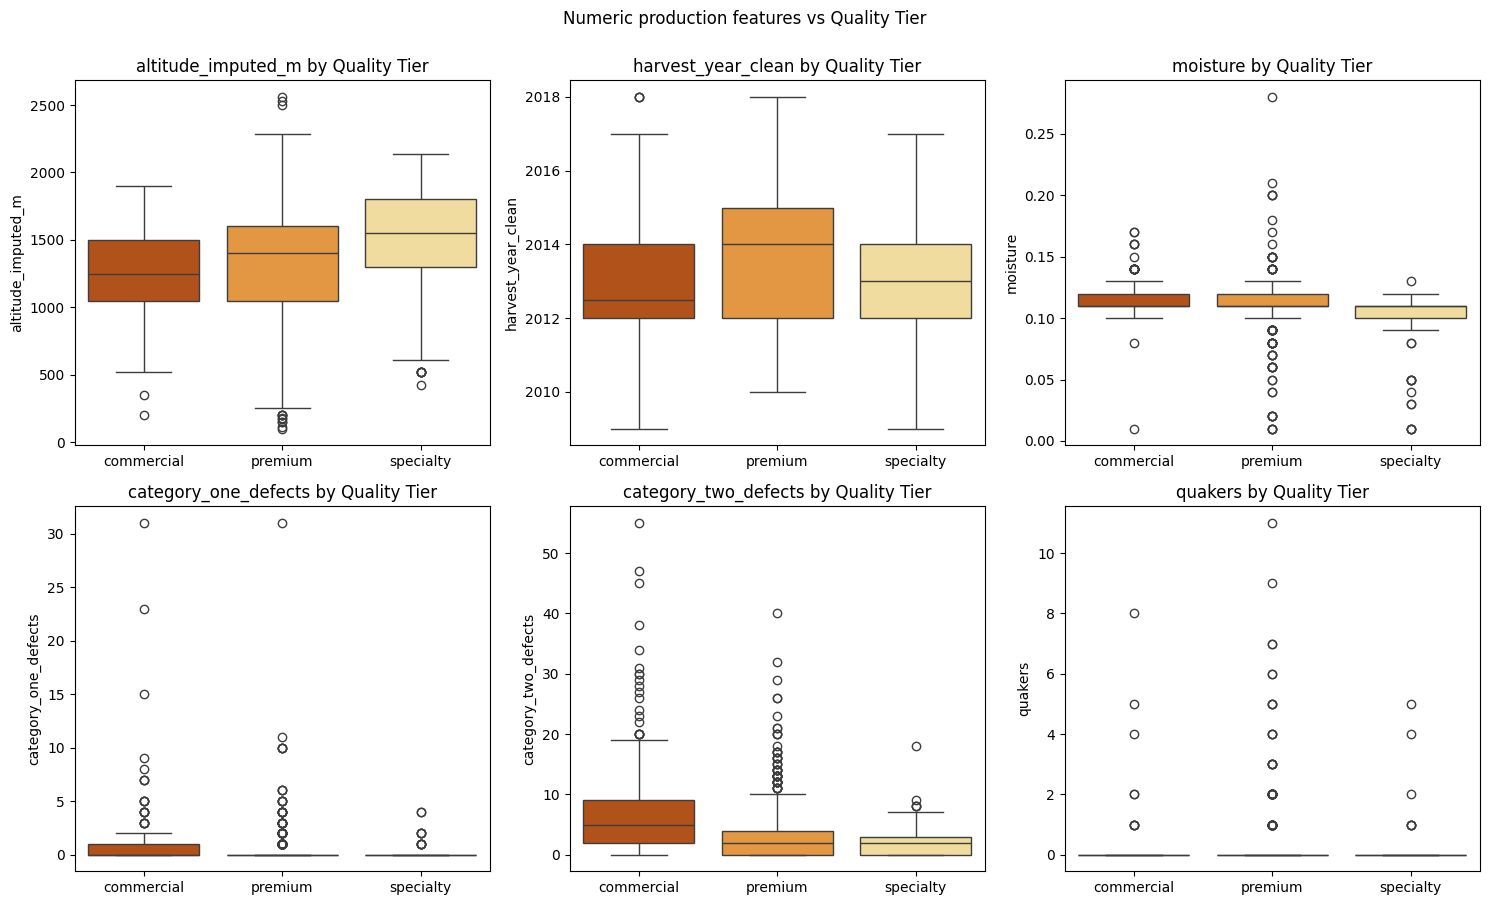

In [36]:
# ============================================================
# III.5 — Bivariate: numeric production features vs Quality Tier
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, col in zip(axes.flatten(), numeric_production):
    sns.boxplot(data=df, x='quality_tier', y=col, order=tier_order,
                hue='quality_tier', palette='YlOrBr', legend=False, ax=ax)
    ax.set_title(f'{col} by Quality Tier')
    ax.set_xlabel('')
plt.suptitle('Numeric production features vs Quality Tier', y=1.00)
plt.tight_layout()
plt.show()

### III.6 categorical vs target

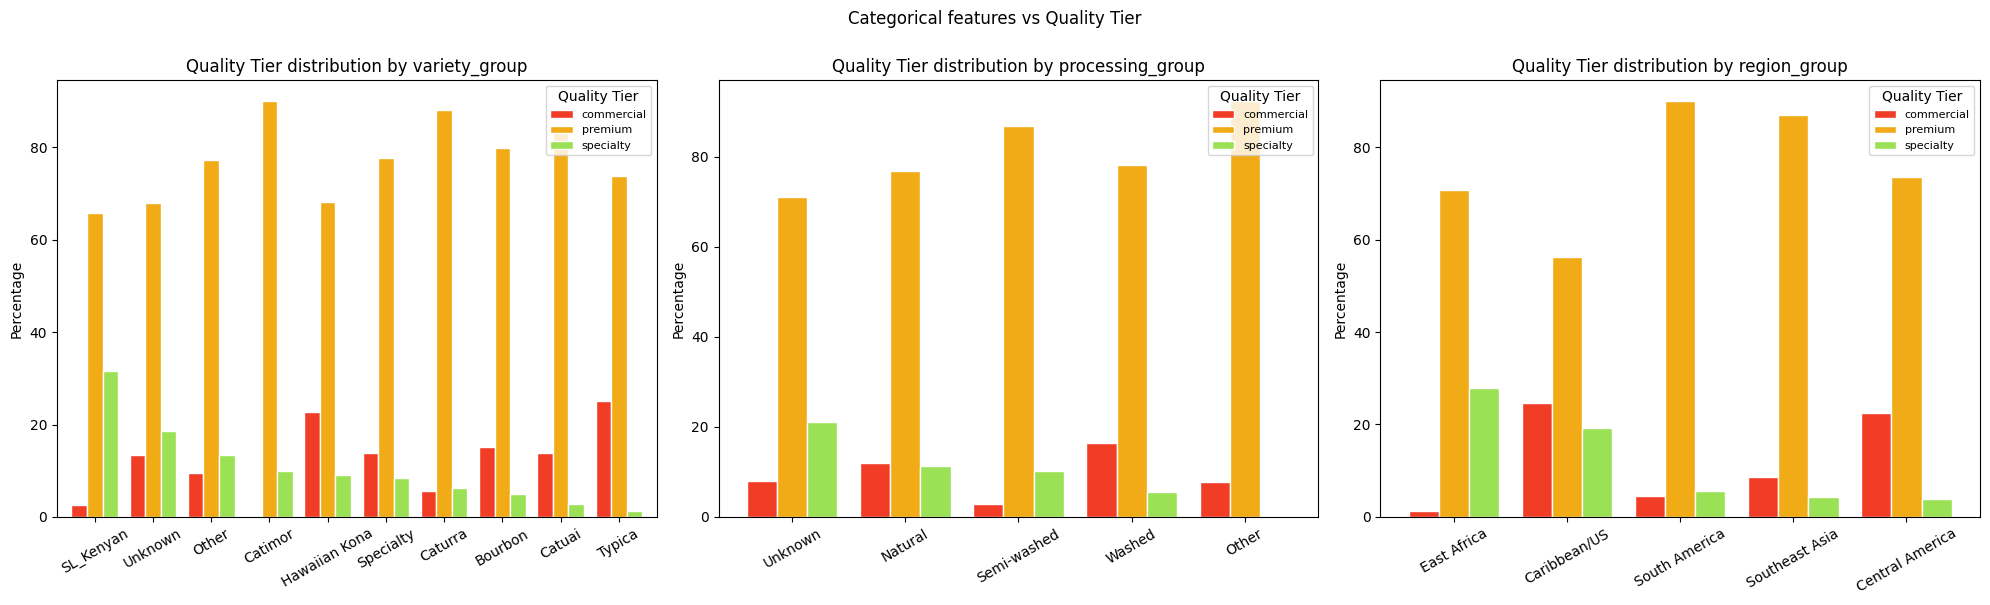

In [37]:
# ============================================================
# III.6 — Bivariate: categorical features vs Quality Tier
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, col in zip(axes, categorical_features):
    # Compute proportion of each tier within each category
    ct = pd.crosstab(df[col], df['quality_tier'], normalize='index') * 100
    ct = ct[tier_order].sort_values('specialty', ascending=False)
    ct.plot(kind='bar', stacked=False, ax=ax,
            color=['#f13c26', '#f1ab17', '#9be155'], edgecolor='white', width=0.8)
    ax.set_title(f'Quality Tier distribution by {col}')
    ax.set_ylabel('Percentage')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Quality Tier', loc='upper right', fontsize=8)
plt.suptitle('Categorical features vs Quality Tier', y=1.00)
plt.tight_layout()
plt.show()

### III.7 correlation heatmap

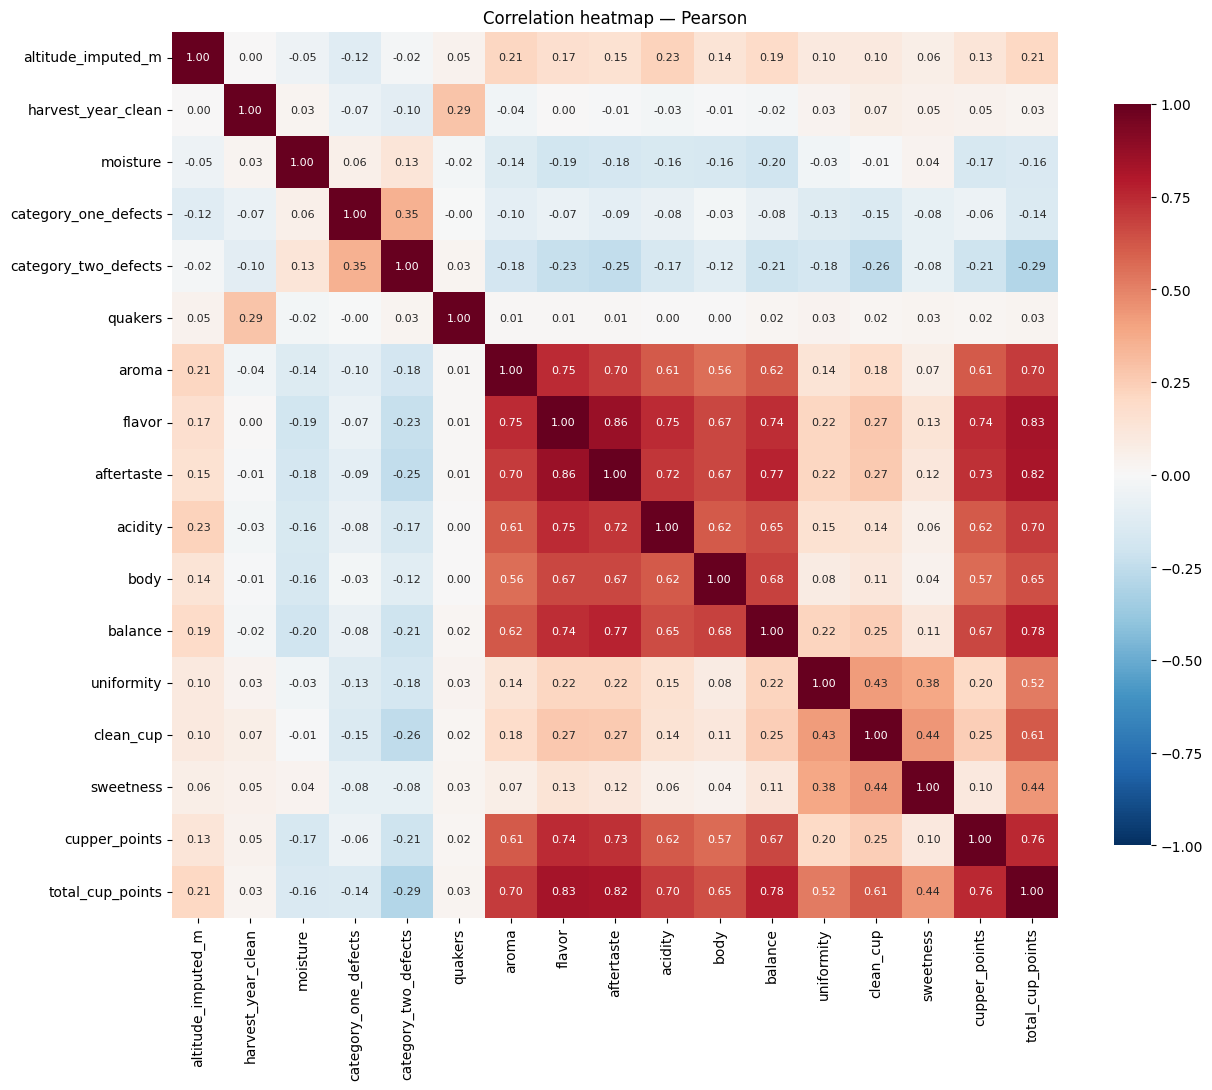

In [38]:
# ============================================================
# III.7 — Correlation heatmap (all numeric features)
# ============================================================

corr_features = numeric_production + sensory_features + ['total_cup_points']
corr = df[corr_features].corr()

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Correlation heatmap — Pearson')
plt.tight_layout()
plt.show()

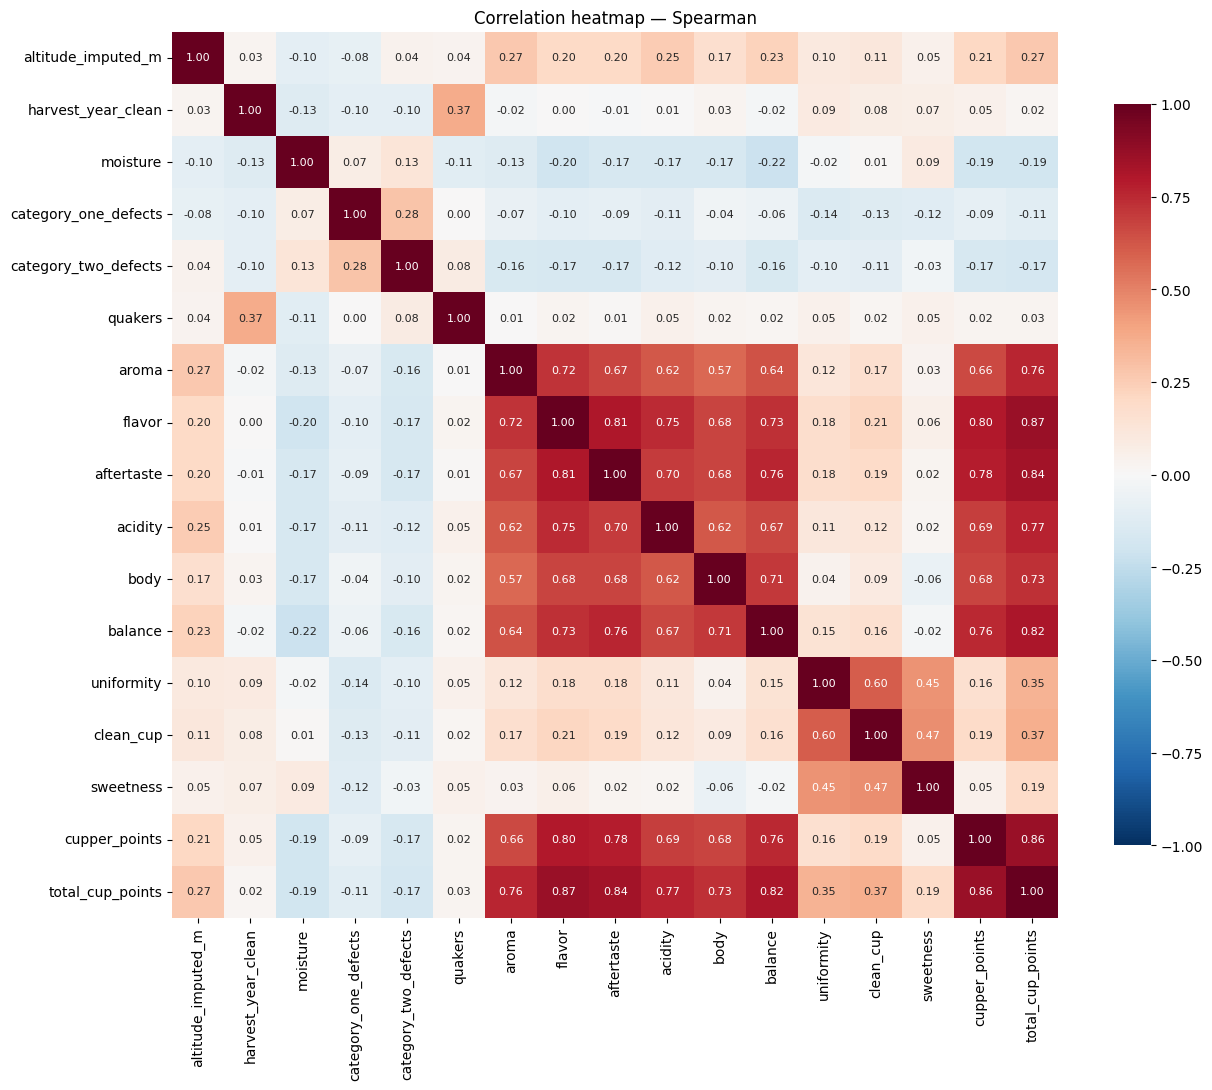

In [39]:
# Spearman correlation for non-linear/monotonic relationships
spearman_corr = df[corr_features].corr(method='spearman')

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Correlation heatmap — Spearman')
plt.tight_layout()
plt.show()

don't use `harvest_year_clean` and `quakers`

### III.8 chi-square tests

In [40]:
# ============================================================
# III.8 — Chi-square tests: categorical features vs quality_tier
# ============================================================

print(f"{'Feature':<20} {'Chi-square':>12} {'dof':>6} {'p-value':>14}")
print("-" * 60)
for col in categorical_features:
    ct = pd.crosstab(df[col], df['quality_tier'])
    chi2, p, dof, expected = chi2_contingency(ct)
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    print(f"{col:<20} {chi2:>12.2f} {dof:>6} {p:>14.2e}  {sig}")

print("\nSignificance: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant")

Feature                Chi-square    dof        p-value
------------------------------------------------------------
variety_group              126.41     18       2.57e-18  ***
processing_group            47.78      8       1.09e-07  ***
region_group               188.98      8       1.34e-36  ***

Significance: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant


## IV. Model Development

### IV.1 feature preparation

In [41]:
# ============================================================
# IV.1 — Feature preparation
# ============================================================

# Model A: production features only (what a farmer/buyer knows without tasting)
production_numeric = ['altitude_imputed_m', 'moisture',
                      'category_one_defects', 'category_two_defects',]
production_categorical = ['variety_group', 'processing_group', 'region_group']

# Model B: single sensory score as baseline
model_b_feature = ['flavor']

# One-hot encode categoricals
X_a_cat = pd.get_dummies(df[production_categorical], drop_first=True)

# Combine numeric + categorical for Model A
X_a = pd.concat([df[production_numeric].reset_index(drop=True),
                 X_a_cat.reset_index(drop=True)], axis=1)

# Model B features and target
X_b = df[model_b_feature].reset_index(drop=True)
y = df['quality_tier'].reset_index(drop=True)

print(f"Model A: {X_a.shape[1]} features "
      f"({len(production_numeric)} numeric + {X_a_cat.shape[1]} one-hot)")
print(f"Model B: {X_b.shape[1]} feature (flavor only)")
print(f"Target: {y.shape[0]} samples across {y.nunique()} classes")
print(f"\nModel A column list:")
for c in X_a.columns:
    print(f"  {c}")

Model A: 21 features (4 numeric + 17 one-hot)
Model B: 1 feature (flavor only)
Target: 1251 samples across 3 classes

Model A column list:
  altitude_imputed_m
  moisture
  category_one_defects
  category_two_defects
  variety_group_Catimor
  variety_group_Catuai
  variety_group_Caturra
  variety_group_Hawaiian Kona
  variety_group_Other
  variety_group_SL_Kenyan
  variety_group_Specialty
  variety_group_Typica
  variety_group_Unknown
  processing_group_Other
  processing_group_Semi-washed
  processing_group_Unknown
  processing_group_Washed
  region_group_Central America
  region_group_East Africa
  region_group_South America
  region_group_Southeast Asia


### IV.2 train/test split and scaling

In [42]:
# ============================================================
# IV.2 — Stratified train/test split + scaling
# ============================================================

X_a_train, X_a_test, y_train, y_test = train_test_split(
    X_a, y, test_size=0.20, random_state=42, stratify=y
)
X_b_train = X_b.loc[X_a_train.index]
X_b_test = X_b.loc[X_a_test.index]

print(f"Train: {len(y_train)} rows | Test: {len(y_test)} rows (stratified on target)")
print("\nClass distribution in each split:")
print(pd.DataFrame({
    'train_n':   y_train.value_counts(),
    'train_pct': (y_train.value_counts(normalize=True) * 100).round(1),
    'test_n':    y_test.value_counts(),
    'test_pct':  (y_test.value_counts(normalize=True) * 100).round(1)
}))

# Scale numeric features; leave dummy columns as 0/1
scaler_a = StandardScaler()
X_a_train_s = X_a_train.copy()
X_a_test_s = X_a_test.copy()
X_a_train_s[production_numeric] = scaler_a.fit_transform(X_a_train[production_numeric])
X_a_test_s[production_numeric] = scaler_a.transform(X_a_test[production_numeric])

# Scale Model B
scaler_b = StandardScaler()
X_b_train_s = pd.DataFrame(scaler_b.fit_transform(X_b_train),
                            columns=X_b_train.columns, index=X_b_train.index)
X_b_test_s = pd.DataFrame(scaler_b.transform(X_b_test),
                           columns=X_b_test.columns, index=X_b_test.index)

print("\nScaling complete (numeric features only).")

Train: 1000 rows | Test: 251 rows (stratified on target)

Class distribution in each split:
              train_n  train_pct  test_n  test_pct
quality_tier                                      
premium           780       78.0     196      78.1
commercial        139       13.9      35      13.9
specialty          81        8.1      20       8.0

Scaling complete (numeric features only).


### IV.3 train four models

In [43]:
# ============================================================
# IV.3 — Train the four models
# ============================================================

# 1. Dummy baseline: always predicts the majority class (premium)
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_a_train_s, y_train)
y_pred_dummy = dummy.predict(X_a_test_s)

# 2. Model A (unbalanced): standard logistic regression on production features
model_a_unb = LogisticRegression(max_iter=2000, random_state=42)
model_a_unb.fit(X_a_train_s, y_train)
y_pred_a_unb = model_a_unb.predict(X_a_test_s)

# 3. Model A (balanced): class_weight='balanced' to correct imbalance
model_a_bal = LogisticRegression(max_iter=2000, random_state=42,
                                  class_weight='balanced', solver='lbfgs')
model_a_bal.fit(X_a_train_s, y_train)
y_pred_a_bal = model_a_bal.predict(X_a_test_s)

# 4. Model B: logistic regression on flavor alone (near-ceiling baseline)
model_b = LogisticRegression(max_iter=1000, random_state=42)
model_b.fit(X_b_train_s, y_train)
y_pred_b = model_b.predict(X_b_test_s)

print("Four models trained:")
print("  1. Dummy (always predicts premium)")
print("  2. Model A — production features, unbalanced")
print("  3. Model A — production features, class-balanced")
print("  4. Model B — single flavor score")

Four models trained:
  1. Dummy (always predicts premium)
  2. Model A — production features, unbalanced
  3. Model A — production features, class-balanced
  4. Model B — single flavor score


## V. Results & Evaluation

### V.1 classification reports

In [44]:
# ============================================================
# V.1 — Per-model classification reports
# ============================================================

predictions = {
    'Dummy (always premium)': y_pred_dummy,
    'Model A (unbalanced)':   y_pred_a_unb,
    'Model A (balanced)':     y_pred_a_bal,
    'Model B (flavor only)':  y_pred_b,
}

for name, y_pred in predictions.items():
    print(f"\n{name}")
    print("=" * 60)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
    print(classification_report(y_test, y_pred, zero_division=0))


Dummy (always premium)
Accuracy: 0.781
              precision    recall  f1-score   support

  commercial       0.00      0.00      0.00        35
     premium       0.78      1.00      0.88       196
   specialty       0.00      0.00      0.00        20

    accuracy                           0.78       251
   macro avg       0.26      0.33      0.29       251
weighted avg       0.61      0.78      0.68       251


Model A (unbalanced)
Accuracy: 0.785
              precision    recall  f1-score   support

  commercial       0.55      0.17      0.26        35
     premium       0.80      0.97      0.88       196
   specialty       0.50      0.05      0.09        20

    accuracy                           0.78       251
   macro avg       0.61      0.40      0.41       251
weighted avg       0.74      0.78      0.73       251


Model A (balanced)
Accuracy: 0.526
              precision    recall  f1-score   support

  commercial       0.28      0.66      0.39        35
     premium   

### V.2 model performance comparison

In [45]:
# ============================================================
# V.2 — Model performance comparison
# ============================================================
from sklearn.metrics import f1_score, precision_score, recall_score

def summarize(y_true, y_pred):
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'macro_f1':  f1_score(y_true, y_pred, average='macro', zero_division=0),
        'precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall':    recall_score(y_true, y_pred, average='macro', zero_division=0),
    }

results = {name: summarize(y_test, y_pred) for name, y_pred in predictions.items()}
results_df = pd.DataFrame(results).T.round(3)

print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)
print(results_df)

MODEL PERFORMANCE COMPARISON
                        accuracy  macro_f1  precision  recall
Dummy (always premium)     0.781     0.292      0.260   0.333
Model A (unbalanced)       0.785     0.409      0.615   0.397
Model A (balanced)         0.526     0.463      0.475   0.644
Model B (flavor only)      0.912     0.832      0.909   0.788


### V.3 comparison chart

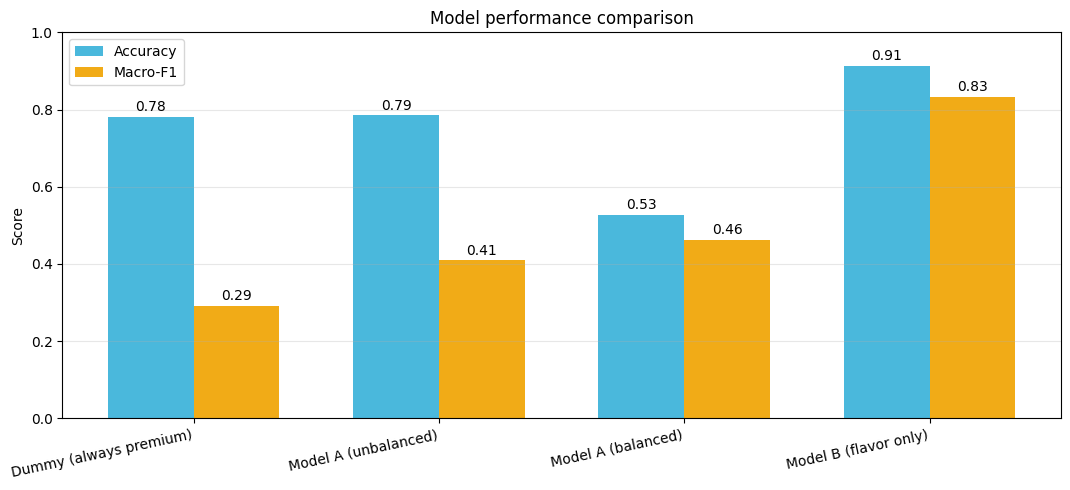

In [46]:
# ============================================================
# V.3 — Performance comparison chart
# ============================================================

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(results_df))
width = 0.35

ax.bar(x - width/2, results_df['accuracy'], width,
       label='Accuracy', color='#4ab8dc')
ax.bar(x + width/2, results_df['macro_f1'], width,
       label='Macro-F1', color='#f1ab17')

ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=12, ha='right')
ax.set_ylabel('Score')
ax.set_title('Model performance comparison')
ax.set_ylim(0, 1)
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)

for i, (acc, f1) in enumerate(zip(results_df['accuracy'], results_df['macro_f1'])):
    ax.text(i - width/2, acc + 0.015, f'{acc:.2f}', ha='center', fontsize=10)
    ax.text(i + width/2, f1 + 0.015, f'{f1:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### V.4 confusion matrices

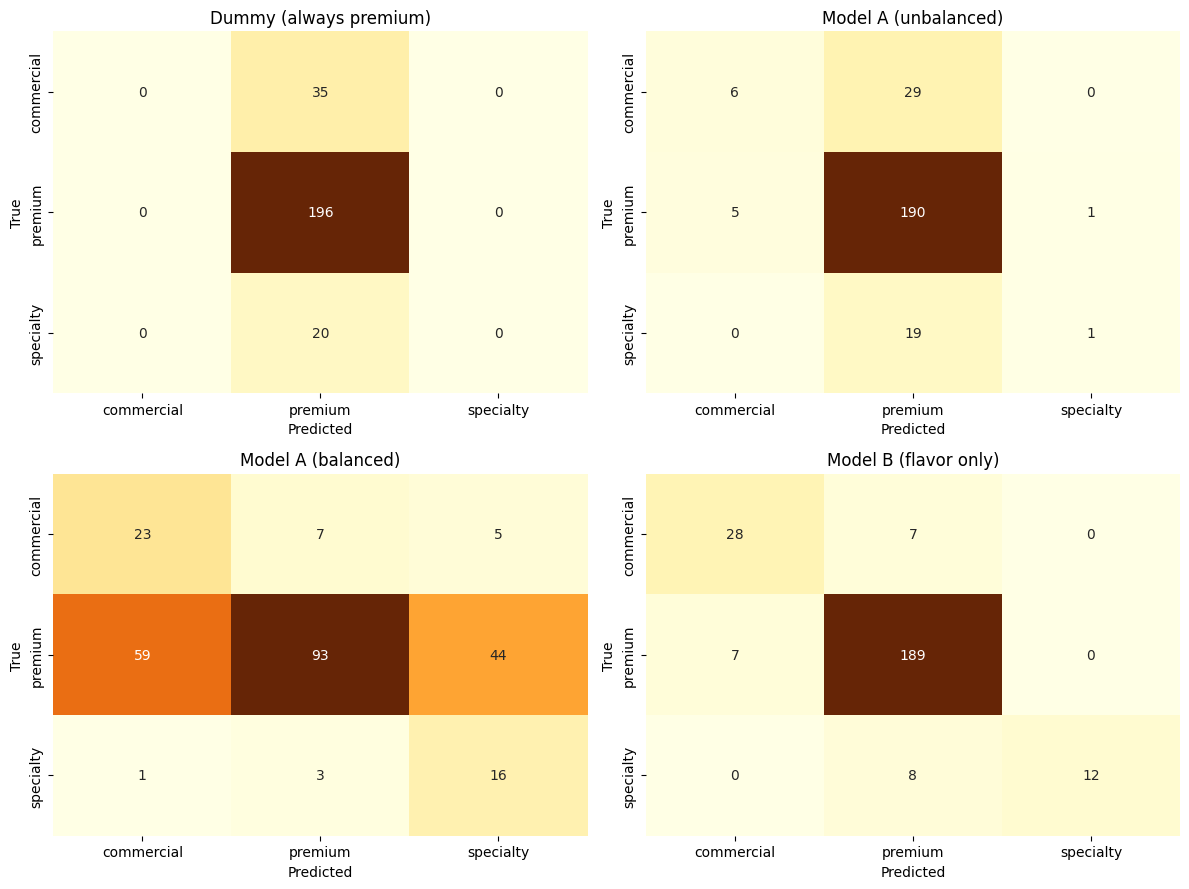

In [47]:
# ============================================================
# V.4 — Confusion matrices
# ============================================================

def plot_cm(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred, labels=tier_order)
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
                xticklabels=tier_order, yticklabels=tier_order,
                cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
plot_cm(y_test, y_pred_dummy, 'Dummy (always premium)', axes[0, 0])
plot_cm(y_test, y_pred_a_unb, 'Model A (unbalanced)',   axes[0, 1])
plot_cm(y_test, y_pred_a_bal, 'Model A (balanced)',     axes[1, 0])
plot_cm(y_test, y_pred_b,     'Model B (flavor only)',  axes[1, 1])
plt.tight_layout()
plt.show()

### V.5 feature importance

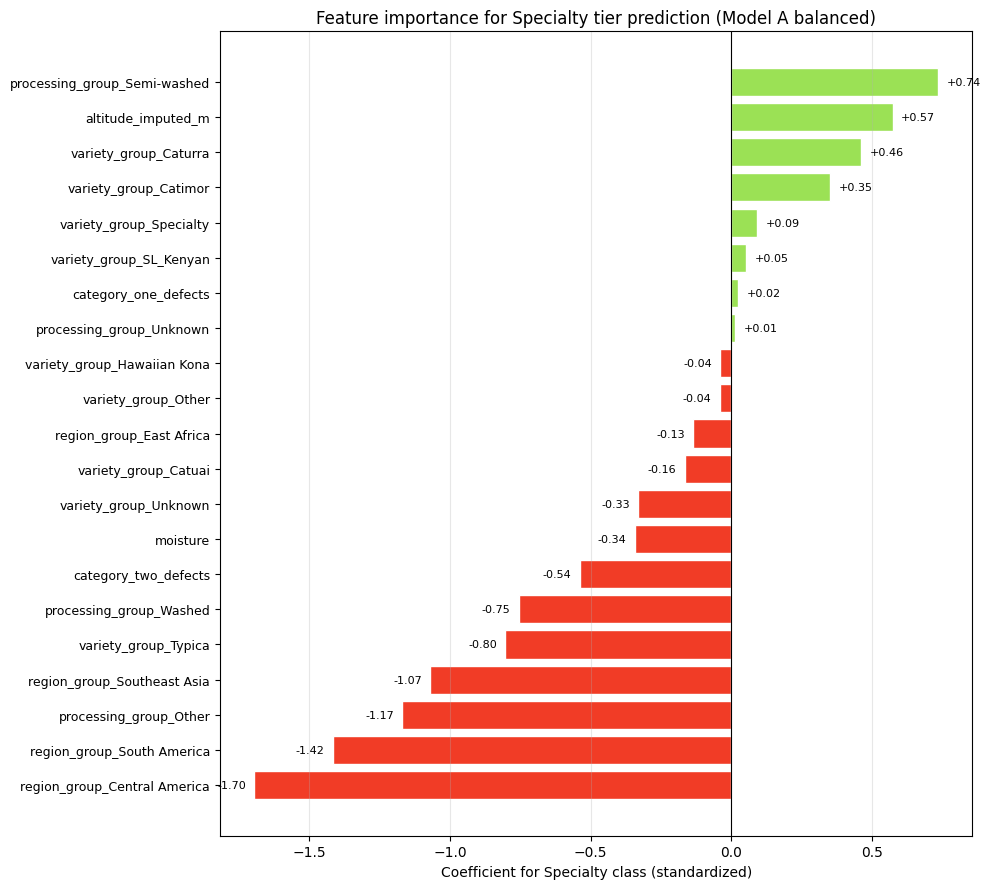

In [48]:
# ============================================================
# V.5 — Feature importance for Specialty prediction
# ============================================================

coef_df = pd.DataFrame(model_a_bal.coef_,
                       columns=X_a_train_s.columns,
                       index=model_a_bal.classes_).T

spec_coefs = coef_df['specialty'].sort_values()

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#f13c26' if v < 0 else '#9be155' for v in spec_coefs.values]
ax.barh(range(len(spec_coefs)), spec_coefs.values, color=colors, edgecolor='white')
ax.set_yticks(range(len(spec_coefs)))
ax.set_yticklabels(spec_coefs.index, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient for Specialty class (standardized)')
ax.set_title('Feature importance for Specialty tier prediction (Model A balanced)')
ax.grid(axis='x', alpha=0.3)

for i, v in enumerate(spec_coefs.values):
    ax.text(v + (0.03 if v >= 0 else -0.03), i, f'{v:+.2f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()